In [1]:
import numpy as np
from pyscf import gto, scf, lo, mp, cc
mol = gto.Mole()
mol.verbose = 4
mol.atom = '''
O   -1.485163346097   -0.114724564047    0.000000000000
H   -1.868415346097    0.762298435953    0.000000000000
H   -0.533833346097    0.040507435953    0.000000000000
O    1.416468653903    0.111264435953    0.000000000000
H    1.746241653903   -0.373945564047   -0.758561000000
H    1.746241653903   -0.373945564047    0.758561000000
'''
mol.basis = 'cc-pvdz'
mol.precision = 1e-10
mol.build()
mf = scf.UHF(mol).density_fit()
mf.kernel()

frozen = 2
mymp = mp.MP2(mf, frozen=frozen)
mymp.kernel()
efull_mp2 = mymp.e_corr
print(f'MP2 Corr = {efull_mp2:.8f}')

mycc = cc.CCSD(mf, frozen=frozen)
mycc.kernel()
efull_ccsd = mycc.e_corr
print(f'CCSD Corr = {efull_ccsd:.8f}')

efull_t = mycc.ccsd_t()
efull_ccsd_t = efull_ccsd + efull_t
print(f'CCSD(T) Corr = {efull_ccsd_t:.8f}')

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-23-generic', version='#23~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue Apr 14 16:11:48 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Tue May 12 10:35:57 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 6
[INPUT] num. electrons = 20
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y               

In [2]:
print(f'MP2 Corr = {efull_mp2:.8f}')
print(f'CCSD Corr = {efull_ccsd:.8f}')
print(f'CCSD(T) Corr = {efull_ccsd_t:.8f}')

MP2 Corr = -0.40609896
CCSD Corr = -0.42461939
CCSD(T) Corr = -0.43105817


In [3]:
mol.aoslice_by_atom()

array([[ 0,  5,  0, 14],
       [ 5,  8, 14, 19],
       [ 8, 11, 19, 24],
       [11, 16, 24, 38],
       [16, 19, 38, 43],
       [19, 22, 43, 48]])

In [4]:
aoslices = mol.aoslice_by_atom()

for ia in range(mol.natm):
    sh0, sh1, p0, p1 = aoslices[ia]
    symb = mol.atom_symbol(ia)        # e.g. 'O', 'H1', 'H@2' (keeps any user labels)
    # elem = mol.atom_pure_symbol(ia)   # e.g. 'O', 'H'        (just the element)
    # Z    = mol.atom_charge(ia)        # nuclear charge
    # xyz  = mol.atom_coord(ia)         # coordinates in Bohr
    print(f"Atom {ia} ({symb})")

Atom 0 (O)
Atom 1 (H)
Atom 2 (H)
Atom 3 (O)
Atom 4 (H)
Atom 5 (H)


In [5]:
mf.mo_occ

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [20]:
from pyscf.lno import ULNOCCSD_T
from pyscf.lno.tools import autofrag_iao

# def test_lno_iao_by_thresh(self):
mol = mycc.mol
mf = mycc._scf
frozen = mycc.frozen

# IAO localization
orbocc_a = mf.mo_coeff[0][:,frozen:np.count_nonzero(mf.mo_occ[0])]
orbocc_b = mf.mo_coeff[1][:,frozen:np.count_nonzero(mf.mo_occ[1])]
lo_coeff_a = lo.iao.iao(mol, orbocc_a)
lo_coeff_b = lo.iao.iao(mol, orbocc_b)
lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, mf.get_ovlp())
lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, mf.get_ovlp())
lo_coeff = [lo_coeff_a, lo_coeff_b]
moliao = lo.iao.reference_mol(mol)

frag_lolist = autofrag_iao(moliao)
print(frag_lolist)

[[0, 1, 2, 3, 4], [5], [6], [7, 8, 9, 10, 11], [12], [13]]


In [24]:
frag_lolist = [[frag,frag] for frag in frag_lolist]
print(frag_lolist)

[[[[0, 1, 2, 3, 4], [0, 1, 2, 3, 4]], [[0, 1, 2, 3, 4], [0, 1, 2, 3, 4]]], [[[5], [5]], [[5], [5]]], [[[6], [6]], [[6], [6]]], [[[7, 8, 9, 10, 11], [7, 8, 9, 10, 11]], [[7, 8, 9, 10, 11], [7, 8, 9, 10, 11]]], [[[12], [12]], [[12], [12]]], [[[13], [13]], [[13], [13]]]]


In [22]:
gamma = 10
threshs = [3e-5,1e-5,3e-6,1e-6]
# refs = [
#     [-0.4054784012,-0.4240686326,-0.4303996712],
#     [-0.4060479828,-0.4245745223,-0.4309965749],
# ]

emp2_iao = np.zeros(len(threshs))
eccsd_iao = np.zeros(len(threshs))
eccsd_t_iao = np.zeros(len(threshs))

for i, thresh in enumerate(threshs):
    mcc = ULNOCCSD_T(mf, lo_coeff, frag_lolist, frozen=frozen).set(verbose=5)
    mcc.lno_thresh = [thresh*gamma,thresh]
    mcc.kernel()
    emp2_iao[i] = mcc.e_corr_pt2
    eccsd_iao[i] = mcc.e_corr_ccsd
    eccsd_t_iao[i] = mcc.e_corr_ccsd_t


******** <class 'pyscf.lno.ulnoccsd.ULNOCCSD_T'> ********
nocc = (np.int64(8), np.int64(8)), nmo = (46, 46)
frozen orbitals 2
max_memory 4000 MB (current use 333 MB)
nfrag = 6  nlo = [14, 14]
frag_lolist = [[[0, 1, 2, 3, 4], [0, 1, 2, 3, 4]], [[5], [5]], [[6], [6]], [[7, 8, 9, 10, 11], [7, 8, 9, 10, 11]], [[12], [12]], [[13], [13]]]
frag_wghtlist = None
lno_type = ['1h', '1h']
lno_thresh = [0.00030000000000000003, 3e-05]
lno_pct_occ = None
lno_norb = None
lo_proj_thresh = 1e-10
lo_proj_thresh_active = 0.1
verbose_imp = 2
_ovL = None
_ovL_to_save = None
force_outcore_ao2mo = False
_match_oldcode = False
_max_las_size_ccsd = 1000
_max_las_size_ccsd_t = 1000
Regularized frag_wghtlist = [1. 1. 1. 1. 1. 1.]
    CPU time for LO and fragment        0.00 sec, wall time      0.00 sec

WARN: Input vhf is not found. Building vhf from SCF MO.

ao2mo est mem= 1.08 MB  avail mem= 3666.70 MB
aux blksize for incore ao2mo (unrestricted): 232/232
    CPU time for Integral xform         0.02 sec, wall t

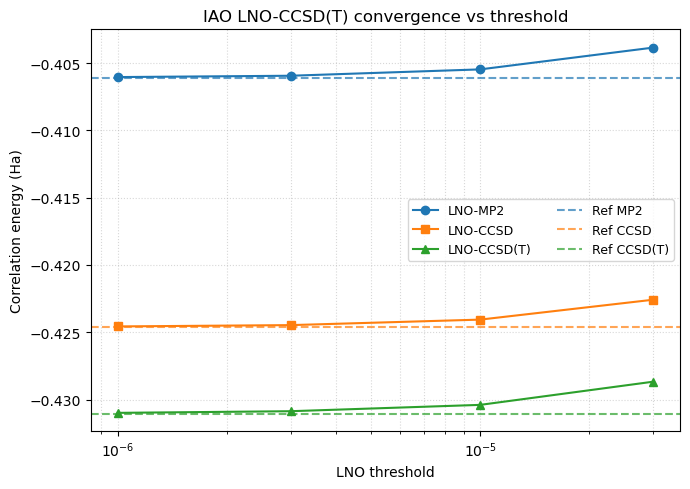

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Computed LNO values vs threshold
ax.plot(threshs, emp2_iao,    'o-', color='tab:blue',   label='LNO-MP2')
ax.plot(threshs, eccsd_iao,   's-', color='tab:orange', label='LNO-CCSD')
ax.plot(threshs, eccsd_t_iao, '^-', color='tab:green',  label='LNO-CCSD(T)')

# Reference (full) values as horizontal dashed lines, color-matched
ax.axhline(efull_mp2,    ls='--', color='tab:blue',   alpha=0.7, label='Ref MP2')
ax.axhline(efull_ccsd,   ls='--', color='tab:orange', alpha=0.7, label='Ref CCSD')
ax.axhline(efull_ccsd_t, ls='--', color='tab:green',  alpha=0.7, label='Ref CCSD(T)')

ax.set_xscale('log')
# ax.invert_xaxis()  # smaller threshold (tighter) on the right -> easier to read convergence
ax.set_xlabel('LNO threshold')
ax.set_ylabel('Correlation energy (Ha)')
ax.set_title('IAO LNO-CCSD(T) convergence vs threshold')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
eccsd_iao

array([-0.4225857 , -0.42406396, -0.42447265, -0.42457045])